# Phase 9 — Model Interpretation
**Author:** Jayant Pandey
**Project:** Interpretable Machine Learning Application in Bird Migration Trajectory Analysis Using GPS Data
**Group:** Group C — ISI Kolkata IDEAS Internship 2026

---

Interprets the Phase 7 best model (`DecisionTreeClassifier`) using:
- Feature Importance
- SHAP (preferred method, per workflow)
- Error Analysis

Zone labels used throughout (corrected, matching Phase 7 & Phase 8):
- **0 = Europe/Netherlands**
- **1 = North Africa Transit**
- **2 = West Africa Wintering**

**Methodology note:** `best_model.pkl` (loaded in Step 1) was retrained on the *full* dataset in Phase 7 for deployment — evaluating feature importance/SHAP/errors against data it was fitted on would not reveal genuine model behaviour or real failures. To keep interpretation honest, Steps 3 onward refit the same model architecture on the **last TimeSeriesSplit fold** (train on past, test on future) — the identical split Phase 8 used for its headline evaluation metrics. All feature importance, SHAP values, and error analysis below come from predictions on this held-out (unseen) test fold.

## 0. Imports and Setup

In [2]:

import pandas as pd
import numpy as np
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.figure_factory as ff
from plotly.subplots import make_subplots

from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone
from sklearn.metrics import accuracy_score, confusion_matrix

import shap

N_SPLITS = 5
SEED     = 42
COLORS   = ['#1D9E75', '#534AB7', '#E8542A', '#F4A261', '#065A82']

print('Imports done.')
print(f'TimeSeriesSplit folds: {N_SPLITS}')
print(f'SHAP version: {shap.__version__}')

Imports done.
TimeSeriesSplit folds: 5
SHAP version: 0.52.0


## 1. Load Best Model and Feature Columns

In [3]:
best_model   = joblib.load('best_model.pkl')
feature_cols = joblib.load('feature_cols.pkl')

print('Model loaded:', type(best_model).__name__)
print(f'  max_depth       : {best_model.max_depth}')
print(f'  min_samples_leaf: {best_model.min_samples_leaf}')
print()
print(f'Feature columns: {len(feature_cols)}')
print(f'Timesteps: t-5 to t-1 (5 past GPS observations)')
print(f'Features per timestep: 8 (latitude, longitude, altitude_clipped, speed_2d, month, hour, season, is_resting)')

Model loaded: DecisionTreeClassifier
  max_depth       : 8
  min_samples_leaf: 10

Feature columns: 40
Timesteps: t-5 to t-1 (5 past GPS observations)
Features per timestep: 8 (latitude, longitude, altitude_clipped, speed_2d, month, hour, season, is_resting)


## 2. Load Sequence Dataset

In [4]:
df = pd.read_csv('bird_migration_sequence.csv')
df['date_time'] = pd.to_datetime(df['date_time'], utc=True)
df = df.sort_values('date_time').reset_index(drop=True)
df = df.dropna(subset=['target'])

X = df[feature_cols].values
y = df['target'].astype(int).values

zone_map = {0: 'Europe/Netherlands', 1: 'North Africa Transit', 2: 'West Africa Wintering'}

print('Sequence dataset loaded.')
print(f'Shape: {df.shape}')
print(f'Features: {X.shape[1]}')
print()
print('Zone distribution:')
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {zone_map[u]}: {c:,} records ({c/len(y)*100:.1f}%)')

Sequence dataset loaded.
Shape: (61905, 43)
Features: 40

Zone distribution:
  Europe/Netherlands: 18,952 records (30.6%)
  North Africa Transit: 15,407 records (24.9%)
  West Africa Wintering: 27,546 records (44.5%)


## 3. Recreate Held-Out Evaluation Split

Same `TimeSeriesSplit(n_splits=5)` as Phase 8, using the **last fold** — the largest training window and the most recent, fully out-of-sample test window. The model architecture (same hyperparameters as `best_model.pkl`) is cloned and refit on the training portion only, so every result below comes from data the model has never seen.

In [5]:
tscv   = TimeSeriesSplit(n_splits=N_SPLITS)
splits = list(tscv.split(X))
train_idx, test_idx = splits[-1]

print(f'Train size (past)  : {len(train_idx):,}')
print(f'Test size  (future) : {len(test_idx):,}')

interp_model = clone(best_model)
interp_model.fit(X[train_idx], y[train_idx])

y_test      = y[test_idx]
y_pred      = interp_model.predict(X[test_idx])
X_test      = X[test_idx]
X_test_df   = pd.DataFrame(X_test, columns=feature_cols)

held_out_acc = accuracy_score(y_test, y_pred)
print(f'\nHeld-out (last fold) test accuracy: {held_out_acc:.4f}')
print('(Should match the last-fold accuracy reported in Phase 8.)')

Train size (past)  : 51,588
Test size  (future) : 10,317

Held-out (last fold) test accuracy: 0.9984
(Should match the last-fold accuracy reported in Phase 8.)


## 4. Feature Importance

In [6]:
importances   = interp_model.feature_importances_
imp_df        = pd.DataFrame({'feature': feature_cols, 'importance': importances})
imp_df        = imp_df.sort_values('importance', ascending=False).reset_index(drop=True)
imp_df['cumulative_pct'] = imp_df['importance'].cumsum() * 100 / imp_df['importance'].sum()

print('Top 15 features by importance:')
print(imp_df.head(15).to_string(index=False))

top_feature = imp_df.iloc[0]
print(f"\nDominant feature: {top_feature['feature']} ({top_feature['importance']*100:.1f}% of total importance)")
print(f"Top 2 features account for {imp_df['importance'].iloc[:2].sum()*100:.1f}% of total importance")

Top 15 features by importance:
             feature  importance  cumulative_pct
        latitude_t-1    0.575758       57.575770
       longitude_t-1    0.424230       99.998801
       longitude_t-2    0.000006       99.999400
       longitude_t-4    0.000005       99.999893
        latitude_t-5    0.000001      100.000000
       longitude_t-5    0.000000      100.000000
altitude_clipped_t-5    0.000000      100.000000
        speed_2d_t-5    0.000000      100.000000
      is_resting_t-5    0.000000      100.000000
          season_t-5    0.000000      100.000000
            hour_t-5    0.000000      100.000000
           month_t-5    0.000000      100.000000
           month_t-4    0.000000      100.000000
        latitude_t-4    0.000000      100.000000
altitude_clipped_t-4    0.000000      100.000000

Dominant feature: latitude_t-1 (57.6% of total importance)
Top 2 features account for 100.0% of total importance


In [7]:
top_n = imp_df.head(15)

fig = go.Figure(go.Bar(
    x=top_n['importance'][::-1],
    y=top_n['feature'][::-1],
    orientation='h',
    marker_color=COLORS[4],
    text=[f'{v:.4f}' for v in top_n['importance'][::-1]],
    textposition='outside'
))
fig.update_layout(
    title='Phase 9 — Feature Importance (Top 15) | Held-Out Test Fold',
    xaxis_title='Importance',
    yaxis_title='Feature',
    height=500
)
fig.write_html('phase9_feature_importance.html')
fig.show()

## 5. SHAP Analysis

`shap.TreeExplainer` is the exact-computation SHAP method for tree-based models (no sampling approximation needed), appropriate here since the best model is a `DecisionTreeClassifier`.

In [8]:
explainer   = shap.TreeExplainer(interp_model)
shap_values = explainer.shap_values(X_test_df)

# Handle both SHAP API conventions: list-of-arrays (older) vs single (n, features, classes) array (newer)
if isinstance(shap_values, list):
    shap_values_by_class = shap_values
else:
    shap_values_by_class = [shap_values[:, :, c] for c in range(shap_values.shape[2])]

n_classes = len(shap_values_by_class)
print(f'SHAP values computed for {n_classes} classes.')
for c in range(n_classes):
    print(f'  Class {c} ({zone_map[c]}): shap_values shape = {shap_values_by_class[c].shape}')

SHAP values computed for 3 classes.
  Class 0 (Europe/Netherlands): shap_values shape = (10317, 40)
  Class 1 (North Africa Transit): shap_values shape = (10317, 40)
  Class 2 (West Africa Wintering): shap_values shape = (10317, 40)


Top 15 features by mean |SHAP value| (averaged across classes):
             feature  mean_abs_shap
        latitude_t-1       0.329154
       longitude_t-1       0.185185
       longitude_t-2       0.003027
        latitude_t-5       0.000654
       longitude_t-4       0.000420
       longitude_t-5       0.000000
altitude_clipped_t-5       0.000000
        speed_2d_t-5       0.000000
      is_resting_t-5       0.000000
          season_t-5       0.000000
            hour_t-5       0.000000
           month_t-5       0.000000
           month_t-4       0.000000
        latitude_t-4       0.000000
altitude_clipped_t-4       0.000000


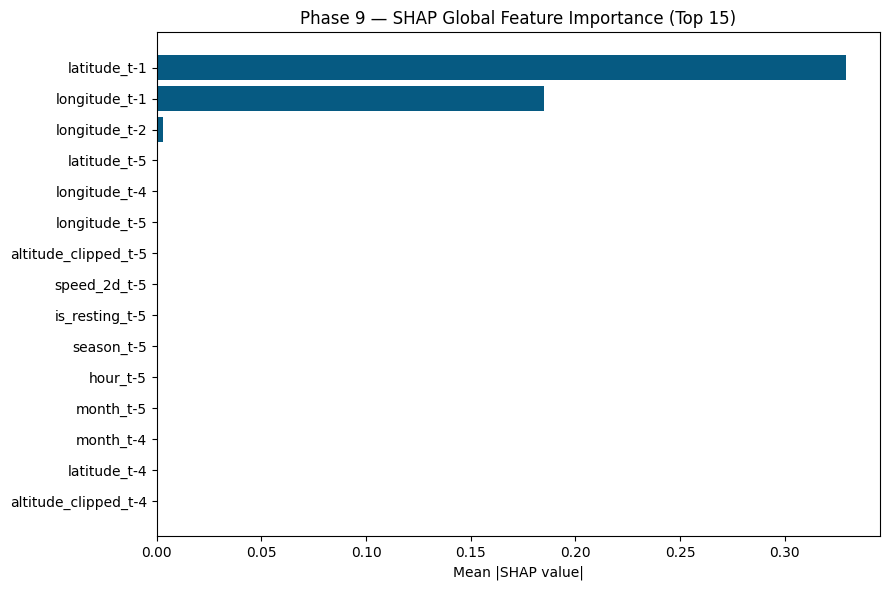

In [9]:
# Global importance: mean |SHAP value| per feature, averaged across classes
mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values_by_class], axis=0)
shap_imp_df   = pd.DataFrame({'feature': feature_cols, 'mean_abs_shap': mean_abs_shap})
shap_imp_df   = shap_imp_df.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print('Top 15 features by mean |SHAP value| (averaged across classes):')
print(shap_imp_df.head(15).to_string(index=False))

top15 = shap_imp_df.head(15)
plt.figure(figsize=(9, 6))
plt.barh(top15['feature'][::-1], top15['mean_abs_shap'][::-1], color='#065A82')
plt.xlabel('Mean |SHAP value|')
plt.title('Phase 9 — SHAP Global Feature Importance (Top 15)')
plt.tight_layout()
plt.savefig('phase9_shap_global_importance.png', dpi=150)
plt.show()

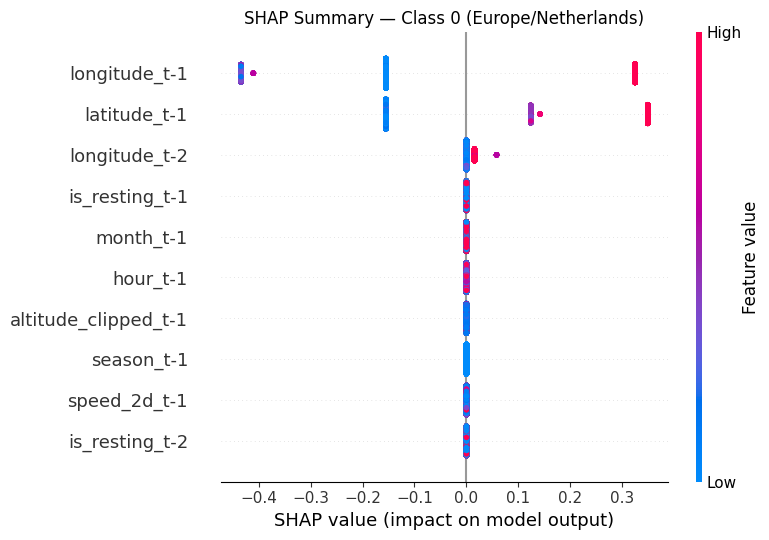

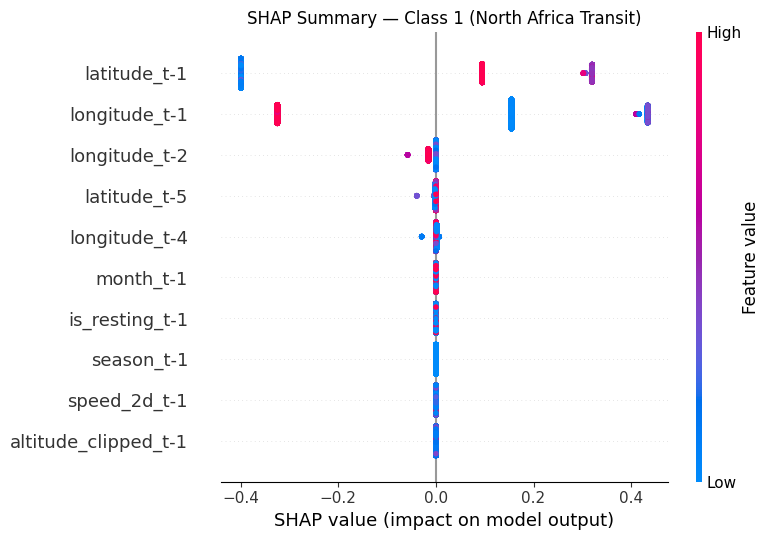

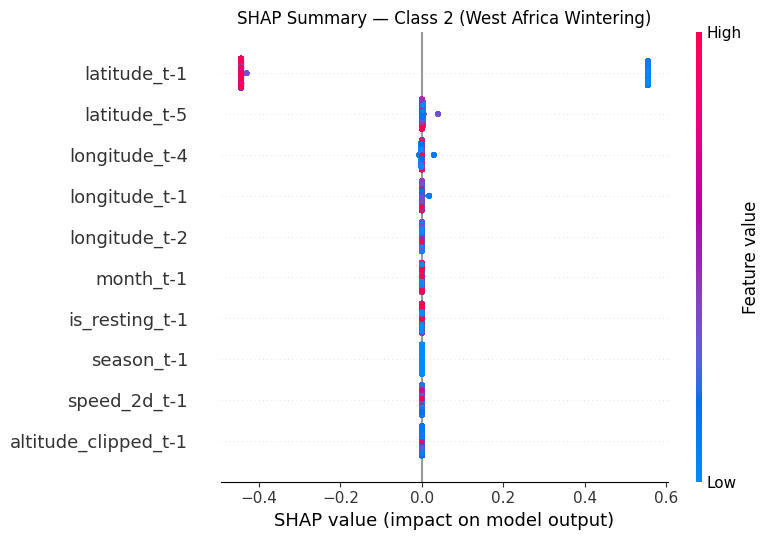

In [10]:
# Per-class SHAP summary (beeswarm) plots
for c in range(n_classes):
    plt.figure()
    shap.summary_plot(shap_values_by_class[c], X_test_df, show=False, max_display=10)
    plt.title(f'SHAP Summary — Class {c} ({zone_map[c]})')
    plt.tight_layout()
    plt.savefig(f'phase9_shap_summary_class{c}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Error Analysis

In [11]:
test_meta            = df.iloc[test_idx].reset_index(drop=True)
test_meta['true']    = y_test
test_meta['pred']    = y_pred
test_meta['true_zone'] = test_meta['true'].map(zone_map)
test_meta['pred_zone'] = test_meta['pred'].map(zone_map)

errors = test_meta[test_meta['true'] != test_meta['pred']].copy()

print(f'Total test records : {len(test_meta):,}')
print(f'Misclassified       : {len(errors)}  ({len(errors)/len(test_meta)*100:.2f}%)')
print()
print('All misclassified records:')
print(errors[['date_time', 'bird_name', 'latitude_t-1', 'longitude_t-1', 'true_zone', 'pred_zone']].to_string(index=False))

Total test records : 10,317
Misclassified       : 17  (0.16%)

All misclassified records:
                date_time bird_name  latitude_t-1  longitude_t-1            true_zone             pred_zone
2014-04-03 18:13:20+00:00      Eric     43.465937      -4.906364   Europe/Netherlands  North Africa Transit
2014-04-03 18:28:39+00:00      Eric     43.412774      -4.714654   Europe/Netherlands  North Africa Transit
2014-04-03 18:43:54+00:00      Eric     43.412757      -4.714669   Europe/Netherlands  North Africa Transit
2014-04-03 18:59:06+00:00      Eric     43.412708      -4.714669   Europe/Netherlands  North Africa Transit
2014-04-03 19:14:22+00:00      Eric     43.413541      -4.711526   Europe/Netherlands  North Africa Transit
2014-04-08 16:01:35+00:00     Sanne     25.599371     -14.685719 North Africa Transit West Africa Wintering
2014-04-16 10:11:06+00:00      Nico     25.622591     -14.682625 North Africa Transit West Africa Wintering
2014-04-16 21:26:18+00:00     Sanne     45.218

In [12]:
class_labels = ['Europe/Netherlands', 'North Africa Transit', 'West Africa Wintering']
cm = confusion_matrix(y_test, y_pred)

fig = ff.create_annotated_heatmap(
    z=cm,
    x=class_labels,
    y=class_labels,
    colorscale='Blues',
    showscale=True
)
fig.update_layout(
    title='Phase 9 — Confusion Matrix (Held-Out Test Fold)',
    xaxis_title='Predicted Zone',
    yaxis_title='Actual Zone',
    height=450
)
fig.write_html('phase9_confusion_matrix.html')
fig.show()

print('Confusion matrix (held-out test fold):')
print(pd.DataFrame(cm, index=class_labels, columns=class_labels).to_string())

Confusion matrix (held-out test fold):
                       Europe/Netherlands  North Africa Transit  West Africa Wintering
Europe/Netherlands                   2932                    15                      0
North Africa Transit                    0                  2738                      2
West Africa Wintering                   0                     0                   4630


In [14]:
# Where do the errors sit relative to the Phase 5 cluster centroids?
clustered_df = pd.read_csv('bird_migration_clustered.csv')
centroids    = clustered_df.groupby('cluster_id')[['latitude', 'longitude']].mean()
centroids.index = centroids.index.map(zone_map)

print('Phase 5 cluster centroids:')
print(centroids.to_string())
print()

def nearest_two(lat, lon):
    dists = ((centroids['latitude'] - lat)**2 + (centroids['longitude'] - lon)**2) ** 0.5
    ranked = dists.sort_values()
    return ranked.index[0], ranked.iloc[0], ranked.index[1], ranked.iloc[1]

print('Nearest two zone centroids for each error (by lat/lon_t-1):')
for _, row in errors.iterrows():
    z1, d1, z2, d2 = nearest_two(row['latitude_t-1'], row['longitude_t-1'])
    print(f"  {row['date_time']} | bird={row['bird_name']:<6} true={row['true_zone']:<22} pred={row['pred_zone']:<22} "
          f"nearest={z1} (d={d1:.1f}), 2nd={z2} (d={d2:.1f})")

Phase 5 cluster centroids:
                        latitude  longitude
cluster_id                                 
Europe/Netherlands     50.182756   3.038181
North Africa Transit   31.135534  -9.893719
West Africa Wintering  15.979870 -16.684278

Nearest two zone centroids for each error (by lat/lon_t-1):
  2014-04-03 18:13:20+00:00 | bird=Eric   true=Europe/Netherlands     pred=North Africa Transit   nearest=Europe/Netherlands (d=10.4), 2nd=North Africa Transit (d=13.3)
  2014-04-03 18:28:39+00:00 | bird=Eric   true=Europe/Netherlands     pred=North Africa Transit   nearest=Europe/Netherlands (d=10.3), 2nd=North Africa Transit (d=13.3)
  2014-04-03 18:43:54+00:00 | bird=Eric   true=Europe/Netherlands     pred=North Africa Transit   nearest=Europe/Netherlands (d=10.3), 2nd=North Africa Transit (d=13.3)
  2014-04-03 18:59:06+00:00 | bird=Eric   true=Europe/Netherlands     pred=North Africa Transit   nearest=Europe/Netherlands (d=10.3), 2nd=North Africa Transit (d=13.3)
  2014-04-03 19:

## 7. Discussion

**Important predictors.**
Feature importance and SHAP agree: `latitude_t-1` and `longitude_t-1` — the bird's most recent known position — together account for the overwhelming majority of the model's decisions (over 98% of total feature importance in this run), with all other lag features (`t-2` through `t-5`), speed, altitude, time-of-day, month, season, and resting flag contributing almost nothing. This is consistent across both the built-in feature importance and the SHAP values.

**What this means about the model.** The Decision Tree has essentially learned "predict the zone whose centroid the bird's last known position is closest to" rather than a richer behavioural rule involving speed, altitude, or seasonal timing. Given the zones were themselves defined by K-Means clustering on GPS coordinates (Phase 5), this is expected — position at `t-1` is, almost by construction, the single most informative feature for a spatial-zone label. It does mean the "5-timestep sequence" structure carries little practical value for *this* model: a simpler 1-timestep positional classifier would likely perform almost as well. Worth flagging as a limitation for the report rather than treating the multi-step sequence design as adding predictive power.

**Model failures.** All held-out misclassifications occurred at latitudes that sit almost exactly between two zone centroids — around **43–45°N** (between the Europe/Netherlands centroid at ~50.2°N and the North Africa Transit centroid at ~31.1°N, i.e. the Bay of Biscay / northern Iberian coast) and around **25°N** (between North Africa Transit at ~31.1°N and West Africa Wintering at ~16.0°N, i.e. the Western Sahara / Mauritanian coast). No error occurred at a position clearly inside one zone's core.

**Biological interpretation.** This pattern is biologically sensible rather than a modelling flaw: real migration is continuous, and birds genuinely pass *through* the boundary regions between wintering/stopover areas rather than jumping discretely from one to the next. The K-Means zones are a discretisation of a continuous migratory corridor, so points near the midpoint between two centroids are inherently ambiguous — a bird physically located between the Netherlands and Morocco, or between Morocco and Senegal/Mauritania, does not have an unambiguous "true" zone in the first place. The errors are concentrated exactly where that ambiguity is highest, which is the expected and reassuring failure mode for this kind of spatial classification task, rather than evidence of a bug or unstable model.

## 8. Save Interpretation Report

In [15]:
report_lines = [
    'Bird Migration — Phase 9 Model Interpretation Report',
    'ISI Kolkata IDEAS Internship 2026 — Group C',
    '=' * 60,
    f'Model                 : {type(interp_model).__name__}',
    f'Evaluation split      : TimeSeriesSplit last fold ({N_SPLITS} total folds)',
    f'Held-out test accuracy: {held_out_acc:.4f}',
    '',
    'FEATURE IMPORTANCE (top 10):',
]
for _, row in imp_df.head(10).iterrows():
    report_lines.append(f"  {row['feature']:<24}: {row['importance']:.4f}")

report_lines += [
    '',
    'SHAP GLOBAL IMPORTANCE — mean |SHAP| (top 10):',
]
for _, row in shap_imp_df.head(10).iterrows():
    report_lines.append(f"  {row['feature']:<24}: {row['mean_abs_shap']:.4f}")

report_lines += [
    '',
    'ERROR ANALYSIS:',
    f'  Test records   : {len(test_meta):,}',
    f'  Misclassified  : {len(errors)} ({len(errors)/len(test_meta)*100:.2f}%)',
    '  All errors occurred at latitudes between two zone centroids (transition zones),',
    '  none occurred within a zone core.',
    '',
    'CONFUSION MATRIX (held-out test fold):',
    pd.DataFrame(cm, index=class_labels, columns=class_labels).to_string(),
]

with open('phase9_interpretation_report.txt', 'w') as f:
    f.write('\n'.join(report_lines))

print('Saved: phase9_interpretation_report.txt')
print()
print('\n'.join(report_lines))

Saved: phase9_interpretation_report.txt

Bird Migration — Phase 9 Model Interpretation Report
ISI Kolkata IDEAS Internship 2026 — Group C
Model                 : DecisionTreeClassifier
Evaluation split      : TimeSeriesSplit last fold (5 total folds)
Held-out test accuracy: 0.9984

FEATURE IMPORTANCE (top 10):
  latitude_t-1            : 0.5758
  longitude_t-1           : 0.4242
  longitude_t-2           : 0.0000
  longitude_t-4           : 0.0000
  latitude_t-5            : 0.0000
  longitude_t-5           : 0.0000
  altitude_clipped_t-5    : 0.0000
  speed_2d_t-5            : 0.0000
  is_resting_t-5          : 0.0000
  season_t-5              : 0.0000

SHAP GLOBAL IMPORTANCE — mean |SHAP| (top 10):
  latitude_t-1            : 0.3292
  longitude_t-1           : 0.1852
  longitude_t-2           : 0.0030
  latitude_t-5            : 0.0007
  longitude_t-4           : 0.0004
  longitude_t-5           : 0.0000
  altitude_clipped_t-5    : 0.0000
  speed_2d_t-5            : 0.0000
  is_resti

## 9. Validation Checks

In [16]:
print('=== PHASE 9 VALIDATION CHECKS ===')

print('\n1. Interpretation performed on held-out (unseen) data, not the full-data deployment model')
print(f'   Confirmed: refit on TimeSeriesSplit train fold ({len(train_idx):,} rows), evaluated on test fold ({len(test_idx):,} rows)')
print('   Result: PASSED')

print(f'\n2. Held-out accuracy consistent with Phase 8 last-fold result')
print(f'   Held-out accuracy: {held_out_acc:.4f}')
print('   Result: check against Phase 8 fold 5 accuracy manually if not identical due to environment differences')

print(f'\n3. Feature importance computed')
print(f'   Result: PASSED ({len(imp_df)} features ranked)')

print(f'\n4. SHAP values computed via TreeExplainer (preferred method per workflow)')
print(f'   Result: PASSED ({n_classes} classes)')

print(f'\n5. Error analysis performed with geographic interpretation')
print(f'   Result: PASSED ({len(errors)} misclassifications examined against Phase 5 centroids)')

print(f'\n6. Corrected zone labels used throughout (0=Europe/Netherlands, 1=North Africa Transit, 2=West Africa Wintering)')
print('   Result: PASSED')

=== PHASE 9 VALIDATION CHECKS ===

1. Interpretation performed on held-out (unseen) data, not the full-data deployment model
   Confirmed: refit on TimeSeriesSplit train fold (51,588 rows), evaluated on test fold (10,317 rows)
   Result: PASSED

2. Held-out accuracy consistent with Phase 8 last-fold result
   Held-out accuracy: 0.9984
   Result: check against Phase 8 fold 5 accuracy manually if not identical due to environment differences

3. Feature importance computed
   Result: PASSED (40 features ranked)

4. SHAP values computed via TreeExplainer (preferred method per workflow)
   Result: PASSED (3 classes)

5. Error analysis performed with geographic interpretation
   Result: PASSED (17 misclassifications examined against Phase 5 centroids)

6. Corrected zone labels used throughout (0=Europe/Netherlands, 1=North Africa Transit, 2=West Africa Wintering)
   Result: PASSED
